In [1]:
#drive.mount('/content/drive',force_remount=True)
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
#from google.colab.patches import cv2_imshow
import scipy
from scipy.optimize import minimize
import requests
from io import BytesIO
from PIL import Image

#!pip install circle-fit

In [2]:

#img=cv2.imread('/content/drive/MyDrive/Ghazinejad Lab Drive/MRS2026Nanocrystals/Grain_Boundaries/A4_SP_009.png')
img=cv2.imread('/Volumes/Blob/largefilesidontreallycareabout/A4_SP_LongEdge_20x_ver2/A4_SP_LongEdge_20x_ver2_01.png')
#img = img[:-110, :, :] # get rid of label, only for full images
cv2.imshow('Raw Image',img)
#cv2.waitKey(2000)

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (49, 49), 0) #need a LOT of blur for shot peened, should probably look in to other denoising/edge detection techniques
#blurred = cv2.GaussianBlur(gray, (15, 15), 0) #worked for not shot peened
thresholded=cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
#cv2_imshow(thresholded)

In [4]:
#the erosion/dialation to get rid of outliers proved unnecessary after getting rid of the bottom text
#re-enabling this to process shot peened image
#nvm too much trouble
#thresholded=cv2.bitwise_not(thresholded)
##thresholded=cv2.erode(thresholded, np.ones((10,10),np.uint8), iterations=2)
#thresholded=cv2.dilate(thresholded, np.ones((10,10),np.uint8), iterations=2)
#cv2_imshow(thresholded)

In [5]:
edges = cv2.Canny(thresholded, 70, 210)
#cv2_imshow(edges)

In [6]:
# Find all contours in the edge detected image
contours, hierarchy = cv2.findContours(edges.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

print(f"Found {len(contours)} contours.")

# List information about each contour
for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    print(f"Contour {i+1}: has {len(contour)} points, area = {area:.2f}")

# Optional: Draw all contours on a copy of the original image
# img_with_all_contours = img.copy()
# cv2.drawContours(img_with_all_contours, contours, -1, (0, 255, 0), 2) # Draw all contours in green
# cv2_imshow(img_with_all_contours)
largest_contour=max(contours, key=len) #the idea here is to ignore all the miniature pores, and just use the edge

Found 12 contours.
Contour 1: has 23 points, area = 2.00
Contour 2: has 6 points, area = 4.00
Contour 3: has 5 points, area = 5.00
Contour 4: has 54 points, area = 1138.50
Contour 5: has 62 points, area = 1159.50
Contour 6: has 40 points, area = 559.50
Contour 7: has 48 points, area = 573.00
Contour 8: has 362 points, area = 63486.50
Contour 9: has 373 points, area = 63896.50
Contour 10: has 16 points, area = 156.50
Contour 11: has 28 points, area = 164.00
Contour 12: has 2580 points, area = 191.00


In [7]:
# Assuming largest_contour has been found and is available

if 'largest_contour' in locals() and largest_contour is not None:
    # Extract points from the largest contour
    # The contour points are in the format [[[x, y]]], so we reshape to (N, 2)
    point_coordinates = largest_contour.reshape(-1, 2)

    print(f"Generated point_coordinates with {len(point_coordinates)} points from the largest contour.")
    #print(point_coordinates[:10])    # show first 10 points
else:
    point_coordinates = np.array([])
    print("largest_contour is not available or is empty. Could not generate point_coordinates.")

Generated point_coordinates with 2580 points from the largest contour.


In [8]:
#this one worked well for the non shot peened case, but I think the contour implementation is more robust
#print(edges)
ys, xs = np.where(edges > 0)

# Stack into (N,2) array of (x,y)
#point_coordinates = np.column_stack((xs, ys))

#print(point_coordinates.shape)   # (N, 2)
#print(point_coordinates[:10])    # show first 10 points

# Clear the previous plot
#plt.clf()

# Plot the points as a scatter plot
#plt.scatter(point_coordinates[:, 0], point_coordinates[:, 1], s=1) # s is marker size

# Invert the y-axis to match image coordinates (optional, depending on desired visualization)
#plt.gca().invert_yaxis()
#plt.title("Extracted Edge Points")
#plt.xlabel("X-coordinate")
#plt.ylabel("Y-coordinate")
#plt.show()

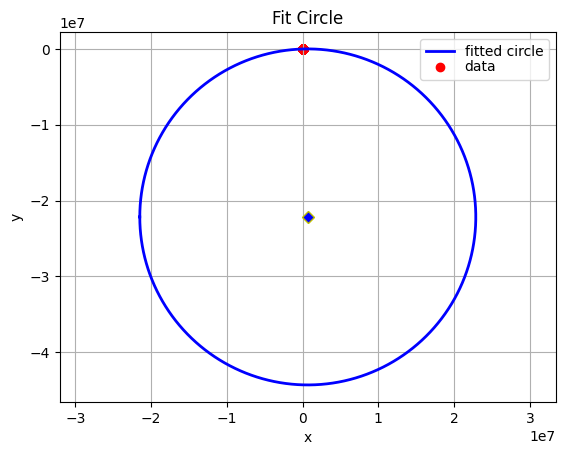

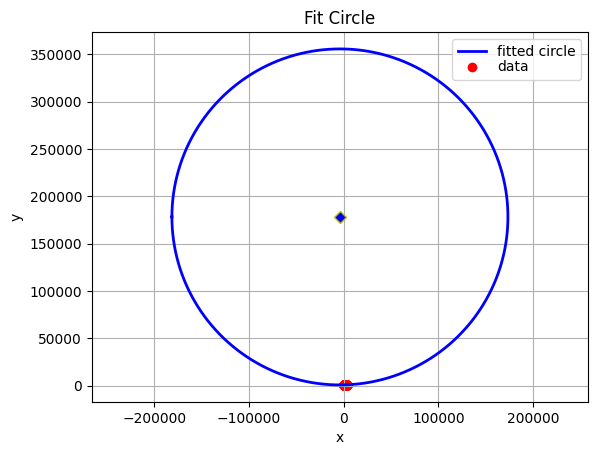

22174878.064664867
5375728.015676332


In [9]:
import circle_fit
from circle_fit import taubinSVD
from circle_fit import standardLSQ
from circle_fit import plot_data_circle
xc, yc, r, sigma = standardLSQ(point_coordinates)
xd,yd,rd,sigmad=taubinSVD(point_coordinates)
plot_data_circle(point_coordinates, xc, yc, r)
plot_data_circle(point_coordinates, xd, yd, rd)
print(r)
print(r/4.125)

In [10]:
# Use the parameters from the standardLSQ fit (xc, yc, r)
# Or use parameters from taubinSVD fit (xd, yd, rd)
# Let's use the standardLSQ parameters for this example

output_img_circle_fit = img.copy()

# Draw the fitted circle from standardLSQ in blue
# Ensure center coordinates are integers
center_x_lsq = int(xc)
center_y_lsq = int(yc)
radius_lsq = int(r)

cv2.circle(output_img_circle_fit, (center_x_lsq, center_y_lsq), radius_lsq, (255, 0, 0), 3)

#cv2_imshow(output_img_circle_fit)

array([[[ 36,  33,  35],
        [ 34,  33,  35],
        [ 33,  35,  35],
        ...,
        [ 44,  51,  50],
        [ 47,  57,  52],
        [ 49,  59,  55]],

       [[ 35,  32,  34],
        [ 33,  32,  34],
        [ 33,  35,  35],
        ...,
        [ 45,  49,  49],
        [ 47,  56,  51],
        [ 47,  57,  54]],

       [[ 35,  32,  34],
        [ 33,  32,  34],
        [ 30,  34,  34],
        ...,
        [ 49,  55,  52],
        [ 49,  62,  53],
        [ 47,  60,  55]],

       ...,

       [[124, 163, 159],
        [124, 162, 158],
        [128, 164, 160],
        ...,
        [141, 205, 179],
        [137, 205, 180],
        [136, 205, 179]],

       [[127, 160, 164],
        [128, 160, 163],
        [131, 161, 164],
        ...,
        [144, 209, 174],
        [141, 209, 174],
        [139, 208, 174]],

       [[125, 156, 162],
        [127, 156, 162],
        [132, 156, 161],
        ...,
        [144, 210, 167],
        [142, 211, 167],
        [140, 209, 166]]

In [11]:
# Find contours in the edge detected image
#contours, hierarchy = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Assuming the largest contour is the main boundary
#if contours:
#    main_contour = max(contours, key=cv2.contourArea)
#    print(f"Found a main contour with {len(main_contour)} points.")

    # Highlight the main contour on the original image
#    img_with_contour = img.copy()
#    cv2.drawContours(img_with_contour, [main_contour], -1, (0, 255, 0), 3) # Draw contour in green with thickness 3
#    cv2_imshow(img_with_contour)

#else:
#    main_contour = None
#    print("No contours found.")

In [12]:
# Overlay the fitted circle on the edges image
edges_with_circle = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR) # Convert edges to BGR to draw color circle
#cv2.circle(edges_with_circle, (int(xc), int(yc)), int(r), (255, 0, 0), 3) # Draw the circle in blue
#cv2_imshow(edges_with_circle)

# Calculate the average absolute orthogonal distance
# We'll iterate through the points in the main_contour and calculate the distance to the fitted circle

distances = []
alldistancesigned=[]
#for point in main_contour[:, 0, :]:
for point in (point_coordinates):
    distance = abs(np.sqrt((point[0] - xc)**2 + (point[1] - yc)**2) - r)
    distancesigned=(np.sqrt((point[0] - xc)**2 + (point[1] - yc)**2) - r)
    alldistancesigned.append(distancesigned)
    distances.append(distance)

average_distance = np.mean(distances)
print(f"Average absolute orthogonal distance to the fitted circle: {average_distance:.2f} pixels")

Average absolute orthogonal distance to the fitted circle: 17.59 pixels


In [13]:
#possible ratios of pixels/micrometer below. Depends if the microscope was correct, at half resolution, or at whole resolution
#figured out with imagej
correct=8.25 #pixels/micrometer
doublemag=4.125 #pixels/micrometer
halfmag=16.5 #pixels/micrometer
correct=4.125 #pixels/micrometer

umdist=np.array(distances) / correct
ra=average_distance / correct

# Convert alldistancesigned to a NumPy array for easier sorting
alldistancesigned_array = np.array(alldistancesigned)

# Sort the signed distances
sorted_distances = np.sort(alldistancesigned_array)

print(f"Average absolute orthogonal distance to the fitted circle: {ra:.2f} micrometers")

# Print the 5 smallest signed distances in micrometers
print("\n5 smallest signed distances (micrometers):")
print(sorted_distances[:5] / correct)

# Print the 5 largest signed distances in micrometers
print("\n5 largest signed distances (micrometers):")
print(sorted_distances[-5:] / correct)
np.set_printoptions(threshold=1000000)
#print(alldistancesigned_array/correct)

Average absolute orthogonal distance to the fitted circle: 4.26 micrometers

5 smallest signed distances (micrometers):
[-11.55247896 -11.55247896 -11.34780161 -11.34780161 -11.3176976 ]

5 largest signed distances (micrometers):
[12.33166021 12.33166021 12.58152544 12.58152544 12.60420212]


In [ ]:
# Visualize the shortest distance lines
output_img_distances = img.copy()
cv2.drawContours(output_img_distances, [point_coordinates], -1, (0, 255, 0), 3) # Original contour in green

# Get the fitted circle parameters
center_x, center_y, radius = xc, yc, r # Using parameters from standardLSQ fit
print(center_x)
print(center_y)
print(radius/correct)

# Draw the fitted circle in blue
#cv2.circle(output_img_distances, (int(center_x), int(center_y)), int(radius), (255, 0, 0), 3)

# Collect the points where the distance lines meet the circle
circle_intersection_points = []

# Draw lines representing the shortest distances
for point in point_coordinates:
    p_x, p_y = point

    # Calculate the vector from the circle center to the contour point
    vector_x = p_x - center_x
    vector_y = p_y - center_y

    # Calculate the distance from the center to the contour point
    dist_to_center = np.sqrt(vector_x**2 + vector_y**2)

    # Handle the case where the contour point is exactly at the center (though unlikely for a contour)
    if dist_to_center == 0:
        closest_point_on_circle_x = center_x + radius
        closest_point_on_circle_y = center_y
    else:
        # Calculate the closest point on the circle
        # This point lies on the line segment connecting the center and the contour point
        closest_point_on_circle_x = center_x + (vector_x / dist_to_center) * radius
        closest_point_on_circle_y = center_y + (vector_y / dist_to_center) * radius

    # Add the intersection point to the list
    circle_intersection_points.append([int(closest_point_on_circle_x), int(closest_point_on_circle_y)])

    # Draw a line from the contour point to the closest point on the circle
    cv2.line(output_img_distances, (p_x, p_y), (int(closest_point_on_circle_x), int(closest_point_on_circle_y)), (0, 0, 255), 1) # Draw line in red


# Convert the list of points to a NumPy array in the correct format for cv2.drawContours
circle_contour = np.array(circle_intersection_points).reshape((-1, 1, 2)).astype(np.int32)

# Draw the contour of the circle intersection points in blue
cv2.drawContours(output_img_distances, [circle_contour], -1, (255, 0, 0), 3) # Draw contour in blue with thickness 3


cv2.imshow("Output",output_img_distances)
key = cv2.waitKey(0) & 0xFF

if key == ord('q'):
    print("Quitting...")
    cv2.destroyAllWindows()
else:
    print(f"Key '{chr(key)}' pressed. Closing window.")
    cv2.destroyAllWindows()

691425.3017609498
-22163249.94403036
5375728.015676332
Quitting...


: 

In [ ]:
from scipy.signal import argrelextrema

# Find the indices of local maxima and minima
local_max_indices = argrelextrema(alldistancesigned_array, np.greater, axis=0, order=10)
local_min_indices = argrelextrema(alldistancesigned_array, np.less, axis=0, order=10)

# Get the values of local maxima and minima
#local_maxima = alldistancesigned_array[local_max_indices]
#local_minima = alldistancesigned_array[local_min_indices]

local_extrema = alldistancesigned_array[np.concatenate((local_max_indices[0], local_min_indices[0]))]


print("\nLocal Extrema (in micrometers):")
print(local_extrema / correct)

#print("\nLocal Maxima (in micrometers):")
#print(local_maxima / correct)

#print("\nLocal Minima (in micrometers):")
#print(local_minima / correct)


Local Extrema (in micrometers):
[ 26.3758407   -9.68707827 -11.81068852 -17.48171741 -19.143987
  17.61463699  17.50191346  -4.47278139  11.15028761   8.80905632
   8.8178764    8.83022986   7.44512569  10.86229724   7.40287344
   8.78797955   8.77562643   8.7668066   11.10803867  -4.51502828
  17.45966824  17.57239211 -19.18622824 -17.52395745 -11.85292671
  -9.72931537  26.33360664 -12.14964445 -15.6584541  -22.50877257
 -19.35693415 -19.47146753  17.33118108 -14.34654223 -13.4330135
   8.38303373   8.56437685   8.44997772  -1.06279209 -11.16522875
 -11.20748142  -1.1050436    8.40772757   8.52212699   8.34078428
 -13.47526095 -14.38878855  17.28893599 -19.5137089  -19.39917524
 -22.55101155 -15.70069164 -12.19188128  23.43325994]
